任务1：独热表示与分布式表示对比

In [16]:
import numpy as np
import pandas as pd
from itertools import combinations

# 1. 独热表示
demo_words = ["猫", "狗", "鸟", "飞机"]
demo_ids = {w: i for i, w in enumerate(demo_words)}
demo_onehot = np.eye(len(demo_words), dtype=float)

print("独热表示：")
print(pd.DataFrame(demo_onehot, index=demo_words, columns=demo_words))

# 2. 从语料统计上下文共现
demo_sentences = [
    "可爱 猫 宠物", "可爱 狗 宠物",
    "家中 猫 陪伴", "家中 狗 陪伴",
    "猫 吃 鱼", "狗 吃 肉",
    "鸟 天空 飞翔", "鸟 树林 飞翔",
    "飞机 天空 飞行", "飞机 机场 飞行",
    "鸟 空中 移动", "飞机 空中 移动",
]

def build_cooccurrence(sentences, words, word_ids):
    tokens = [s.split() for s in sentences]
    contexts = sorted({w for sent in tokens for w in sent} - set(words))
    context_ids = {w: i for i, w in enumerate(contexts)}
    counts = np.zeros((len(words), len(contexts)), dtype=float)
    for sent in tokens:
        for pos, word in enumerate(sent):
            if word not in word_ids:
                continue
            for j in range(max(0, pos - 2), min(len(sent), pos + 3)):
                if j != pos and sent[j] in context_ids:
                    counts[word_ids[word], context_ids[sent[j]]] += 1
    return counts, contexts

demo_counts, demo_contexts = build_cooccurrence(demo_sentences, demo_words, demo_ids)
print("\n共现矩阵：")
print(pd.DataFrame(demo_counts, index=demo_words, columns=demo_contexts).to_string())

# 3. 截断 SVD 获取 3 维分布式表示
def get_svd_dense(counts):
    x = counts / np.maximum(np.linalg.norm(counts, axis=1, keepdims=True), 1e-12)
    u, s, _ = np.linalg.svd(x, full_matrices=False)
    dense = u[:, :3] * s[:3]
    return dense

demo_dense = get_svd_dense(demo_counts)
print("\n分布式表示 (SVD 3维)：")
print(pd.DataFrame(demo_dense, index=demo_words, columns=["维度1", "维度2", "维度3"]).round(4))

# 4. 指标对比
def compare_representations(words, onehot_vectors, dense_vectors):
    records = []
    for i, j in combinations(range(len(words)), 2):
        row = {"词对": f"{words[i]}—{words[j]}"}
        for label, vectors in [("独热", onehot_vectors), ("分布式", dense_vectors)]:
            a, b = vectors[i], vectors[j]
            denominator = np.linalg.norm(a) * np.linalg.norm(b)
            row[f"{label}_欧氏距离"] = float(np.linalg.norm(a - b))
            row[f"{label}_余弦相似度"] = float(a @ b / denominator) if denominator > 0 else np.nan
        records.append(row)
    return pd.DataFrame(records)

demo_comparison = compare_representations(demo_words, demo_onehot, demo_dense)
print("\n指标对比表：")
print(demo_comparison.round(4).to_string(index=False))

# 5. 余弦相似度矩阵
def row_cosine_matrix(vectors):
    normalized = vectors / np.maximum(np.linalg.norm(vectors, axis=1, keepdims=True), 1e-12)
    return normalized @ normalized.T

print("\n独热表示余弦相似度矩阵：")
print(pd.DataFrame(row_cosine_matrix(demo_onehot), index=demo_words, columns=demo_words).round(4))
print("\n分布式表示余弦相似度矩阵：")
print(pd.DataFrame(row_cosine_matrix(demo_dense), index=demo_words, columns=demo_words).round(4))

# 6. 语料扰动消融对比
modified_sentences = demo_sentences.copy()
modified_sentences[3] = "狗 天空 飞行"

mod_counts, _ = build_cooccurrence(modified_sentences, demo_words, demo_ids)
mod_dense = get_svd_dense(mod_counts)
mod_comparison = compare_representations(demo_words, demo_onehot, mod_dense)

cat_dog_orig = demo_comparison.loc[demo_comparison["词对"] == "猫—狗", "分布式_余弦相似度"].values[0]
cat_dog_mod = mod_comparison.loc[mod_comparison["词对"] == "猫—狗", "分布式_余弦相似度"].values[0]
print(f"\n语料修改后 猫—狗 相似度变化: {cat_dog_orig:.4f} -> {cat_dog_mod:.4f}")

独热表示：
      猫    狗    鸟   飞机
猫   1.0  0.0  0.0  0.0
狗   0.0  1.0  0.0  0.0
鸟   0.0  0.0  1.0  0.0
飞机  0.0  0.0  0.0  1.0

共现矩阵：
     可爱    吃   天空   宠物   家中   机场   树林   移动   空中    肉   陪伴   飞翔   飞行    鱼
猫   1.0  1.0  0.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  1.0
狗   1.0  1.0  0.0  1.0  1.0  0.0  0.0  0.0  0.0  1.0  1.0  0.0  0.0  0.0
鸟   0.0  0.0  1.0  0.0  0.0  0.0  1.0  1.0  1.0  0.0  0.0  2.0  0.0  0.0
飞机  0.0  0.0  1.0  0.0  0.0  1.0  0.0  1.0  1.0  0.0  0.0  0.0  2.0  0.0

分布式表示 (SVD 3维)：
       维度1     维度2    维度3
猫  -0.9574  0.0000  0.000
狗  -0.9574  0.0000  0.000
鸟   0.0000 -0.8292 -0.559
飞机  0.0000 -0.8292  0.559

指标对比表：
  词对  独热_欧氏距离  独热_余弦相似度  分布式_欧氏距离  分布式_余弦相似度
 猫—狗   1.4142       0.0    0.0000      1.000
 猫—鸟   1.4142       0.0    1.3844      0.000
猫—飞机   1.4142       0.0    1.3844      0.000
 狗—鸟   1.4142       0.0    1.3844      0.000
狗—飞机   1.4142       0.0    1.3844      0.000
鸟—飞机   1.4142       0.0    1.1180      0.375

独热表示余弦相似度矩阵：
      猫    狗    鸟   飞机


任务2：构造上下文窗口与训练样本

In [9]:
from collections import Counter

# 1. 小型语料准备
sentences = [
    "猫 喜欢 吃 鱼",
    "狗 喜欢 吃 肉",
    "猫 和 狗 都 是 宠物",
    "小猫 是 可爱 的 宠物",
    "小狗 是 忠诚 的 宠物",
    "鱼 生活 在 水中",
    "鸟 喜欢 在 天空 飞翔",
    "飞机 在 天空 飞行",
]

corpus = " ".join(sentences).split()
print("语料词数：", len(corpus))
print("前20个词：", corpus[:20])

# 2. 建立词表
word_counts = Counter(corpus)
vocab = sorted(word_counts, key=word_counts.get, reverse=True)
word_to_id = {word: i for i, word in enumerate(vocab)}
id_to_word = {i: word for word, i in word_to_id.items()}

print("\n词表大小：", len(vocab))
print("词表：", vocab)

# 3. 构造 Skip-gram 训练样本
def make_skipgram_pairs(tokens, word_to_id, window_size=1):
    pairs = []
    for center_pos, center_word in enumerate(tokens):
        center_id = word_to_id[center_word]
        left = max(0, center_pos - window_size)
        right = min(len(tokens), center_pos + window_size + 1)

        for context_pos in range(left, right):
            if context_pos == center_pos:
                continue
            context_word = tokens[context_pos]
            pairs.append((center_id, word_to_id[context_word]))
    return pairs

sentence_tokens = [sentence.split() for sentence in sentences]
pairs = [pair for tokens in sentence_tokens
         for pair in make_skipgram_pairs(tokens, word_to_id, window_size=1)]

print("\n训练样本数：", len(pairs))
print("前10个训练样本：")
for center_id, context_id in pairs[:10]:
    print(id_to_word[center_id], "→", id_to_word[context_id])

# 4. 比较不同窗口大小
print("\n不同窗口大小样本数：")
for window_size in [1, 2, 3]:
    current_pairs = [pair for tokens in sentence_tokens
                     for pair in make_skipgram_pairs(tokens, word_to_id, window_size)]
    print(f"窗口大小={window_size}, 样本数={len(current_pairs)}")

语料词数： 37
前20个词： ['猫', '喜欢', '吃', '鱼', '狗', '喜欢', '吃', '肉', '猫', '和', '狗', '都', '是', '宠物', '小猫', '是', '可爱', '的', '宠物', '小狗']

词表大小： 23
词表： ['喜欢', '是', '宠物', '在', '猫', '吃', '鱼', '狗', '的', '天空', '肉', '和', '都', '小猫', '可爱', '小狗', '忠诚', '生活', '水中', '鸟', '飞翔', '飞机', '飞行']

训练样本数： 58
前10个训练样本：
猫 → 喜欢
喜欢 → 猫
喜欢 → 吃
吃 → 喜欢
吃 → 鱼
鱼 → 吃
狗 → 喜欢
喜欢 → 狗
喜欢 → 吃
吃 → 喜欢

不同窗口大小样本数：
窗口大小=1, 样本数=58
窗口大小=2, 样本数=100
窗口大小=3, 样本数=126


任务3：实现并训练 Skip-gram 词向量模型

中心词张量形状： torch.Size([58])
上下文词张量形状： torch.Size([58])
epoch=200, loss=0.9814
epoch=400, loss=0.9808
epoch=600, loss=0.9806
epoch=800, loss=0.9805
epoch=1000, loss=0.9805


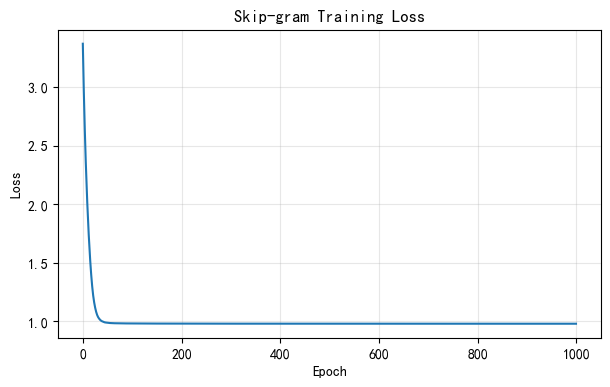

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

# 1. 准备张量数据
centers = torch.tensor([p[0] for p in pairs], dtype=torch.long)
contexts = torch.tensor([p[1] for p in pairs], dtype=torch.long)

print("中心词张量形状：", centers.shape)
print("上下文词张量形状：", contexts.shape)

# 2. 定义 Skip-gram 模型
class SkipGram(nn.Module):
    def __init__(self, vocab_size, embedding_dim=10):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, center_words):
        vectors = self.embedding(center_words)
        logits = self.output(vectors)
        return logits

# 3. 训练模型
embedding_dim = 10
model = SkipGram(len(vocab), embedding_dim=embedding_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.03)

loss_history = []

for epoch in range(1000):
    optimizer.zero_grad()
    logits = model(centers)
    loss = criterion(logits, contexts)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 200 == 0:
        print(f"epoch={epoch + 1}, loss={loss.item():.4f}")

# 4. 绘制损失曲线
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Skip-gram Training Loss")
plt.grid(alpha=0.3)
plt.show()

任务4：词向量相似度分析

In [11]:
import torch.nn.functional as F

# 1. 提取词向量
embeddings = model.embedding.weight.detach()
print("词向量矩阵形状：", embeddings.shape)

# 2. 计算余弦相似度
def cosine_similarity(word_a, word_b):
    vec_a = embeddings[word_to_id[word_a]].unsqueeze(0)
    vec_b = embeddings[word_to_id[word_b]].unsqueeze(0)
    return F.cosine_similarity(vec_a, vec_b).item()

print("\n指定词对余弦相似度：")
for pair in [("猫", "狗"), ("天空", "飞机"), ("猫", "飞机"), ("鱼", "水中")]:
    print(pair, round(cosine_similarity(*pair), 4))

# 3. 查询最相似词
def most_similar(word, top_k=5):
    target_id = word_to_id[word]
    target = embeddings[target_id].unsqueeze(0)
    similarities = F.cosine_similarity(target, embeddings)

    result = []
    for idx in torch.argsort(similarities, descending=True):
        idx = idx.item()
        if idx == target_id:
            continue
        result.append((id_to_word[idx], float(similarities[idx])))
        if len(result) >= top_k:
            break
    return result

print("\n最相似词查询 (Top-5)：")
for word in ["猫", "狗", "天空", "宠物"]:
    sim_list = [f"{w}({s:.4f})" for w, s in most_similar(word)]
    print(f"{word} 的相似词：", ", ".join(sim_list))

# 4. 与独热表示对比
trained_compare_words = ["猫", "狗", "鸟", "飞机"]
trained_ids = [word_to_id[w] for w in trained_compare_words]
trained_vectors = embeddings[trained_ids].cpu().numpy()
trained_onehot = np.eye(len(vocab), dtype=float)[trained_ids]

trained_comparison = compare_representations(trained_compare_words, trained_onehot, trained_vectors)
print("\n训练后向量与独热表示指标对比表：")
print(trained_comparison.round(4).to_string(index=False))

词向量矩阵形状： torch.Size([23, 10])

指定词对余弦相似度：
('猫', '狗') 0.7484
('天空', '飞机') 0.5342
('猫', '飞机') 0.3546
('鱼', '水中') -0.3721

最相似词查询 (Top-5)：
猫 的相似词： 狗(0.7484), 鸟(0.4791), 在(0.4497), 飞翔(0.3977), 飞行(0.3627)
狗 的相似词： 猫(0.7484), 鸟(0.3281), 忠诚(0.2171), 飞翔(0.2064), 在(0.1794)
天空 的相似词： 水中(0.6923), 飞机(0.5342), 鸟(0.3054), 生活(0.2645), 喜欢(0.1434)
宠物 的相似词： 可爱(0.8576), 忠诚(0.7224), 小猫(0.5098), 小狗(0.4703), 都(0.2354)

训练后向量与独热表示指标对比表：
  词对  独热_欧氏距离  独热_余弦相似度  分布式_欧氏距离  分布式_余弦相似度
 猫—狗   1.4142       0.0    4.2782     0.7484
 猫—鸟   1.4142       0.0    5.8128     0.4791
猫—飞机   1.4142       0.0    6.3370     0.3546
 狗—鸟   1.4142       0.0    5.9454     0.3281
狗—飞机   1.4142       0.0    6.4824     0.1669
鸟—飞机   1.4142       0.0    6.6238    -0.0466


任务5：词向量二维可视化 (PCA)

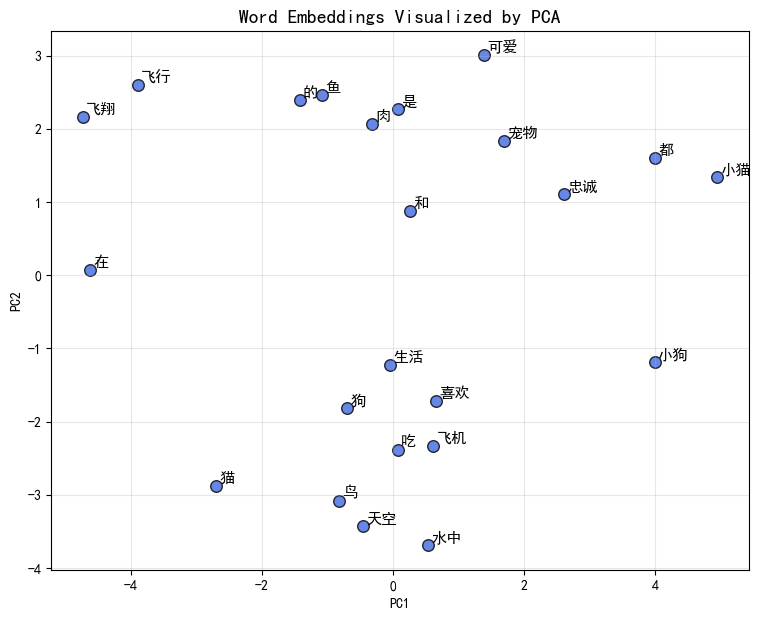

In [12]:
from sklearn.decomposition import PCA

# 支持中文字体
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

vectors = embeddings.cpu().numpy()
pca = PCA(n_components=2)
points = pca.fit_transform(vectors)

plt.figure(figsize=(9, 7))
plt.scatter(points[:, 0], points[:, 1], color="royalblue", edgecolors="black", s=70, alpha=0.8)

for i, word in enumerate(vocab):
    plt.text(points[i, 0] + 0.05, points[i, 1] + 0.05, word, fontsize=11)

plt.title("Word Embeddings Visualized by PCA", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

提高任务：CBOW 模型对比实现

In [13]:
# 1. 构造 CBOW 样本 (上下文列表 -> 中心词)
def make_cbow_pairs(tokens, word_to_id, window_size=1):
    pairs = []
    for center_pos, center_word in enumerate(tokens):
        center_id = word_to_id[center_word]
        left = max(0, center_pos - window_size)
        right = min(len(tokens), center_pos + window_size + 1)
        context_ids = [word_to_id[tokens[i]] for i in range(left, right) if i != center_pos]
        if context_ids:
            pairs.append((context_ids, center_id))
    return pairs

cbow_pairs = [pair for tokens in sentence_tokens
              for pair in make_cbow_pairs(tokens, word_to_id, window_size=1)]

print(f"CBOW (window_size=1) 训练样本数: {len(cbow_pairs)}")
print("前5个 CBOW 样本：")
for contexts, center in cbow_pairs[:5]:
    ctx_words = [id_to_word[c] for c in contexts]
    print(f"上下文: {ctx_words} → 中心词: {id_to_word[center]}")

# 2. 定义 CBOW 模型
class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim=10):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, context_indices_list):
        batch_vectors = []
        for ctx in context_indices_list:
            ctx_tensor = torch.tensor(ctx, dtype=torch.long)
            vec = self.embedding(ctx_tensor).mean(dim=0)
            batch_vectors.append(vec)
        stacked = torch.stack(batch_vectors)
        return self.output(stacked)

# 3. 训练 CBOW 模型
cbow_model = CBOW(len(vocab), embedding_dim=10)
cbow_criterion = nn.CrossEntropyLoss()
cbow_optimizer = optim.Adam(cbow_model.parameters(), lr=0.03)

all_contexts = [p[0] for p in cbow_pairs]
all_targets = torch.tensor([p[1] for p in cbow_pairs], dtype=torch.long)

for epoch in range(1000):
    cbow_optimizer.zero_grad()
    cbow_logits = cbow_model(all_contexts)
    cbow_loss = cbow_criterion(cbow_logits, all_targets)
    cbow_loss.backward()
    cbow_optimizer.step()

    if (epoch + 1) % 200 == 0:
        print(f"epoch={epoch + 1}, loss={cbow_loss.item():.4f}")

# 4. 词对相似度
cbow_embeddings = cbow_model.embedding.weight.detach()

def cbow_cosine(word_a, word_b):
    va = cbow_embeddings[word_to_id[word_a]].unsqueeze(0)
    vb = cbow_embeddings[word_to_id[word_b]].unsqueeze(0)
    return F.cosine_similarity(va, vb).item()

print("\nCBOW 训练后词对余弦相似度：")
for pair in [("猫", "狗"), ("天空", "飞机"), ("猫", "飞机"), ("鱼", "水中")]:
    print(pair, round(cbow_cosine(*pair), 4))

CBOW (window_size=1) 训练样本数: 37
前5个 CBOW 样本：
上下文: ['喜欢'] → 中心词: 猫
上下文: ['猫', '吃'] → 中心词: 喜欢
上下文: ['喜欢', '鱼'] → 中心词: 吃
上下文: ['吃'] → 中心词: 鱼
上下文: ['喜欢'] → 中心词: 狗
epoch=200, loss=0.4179
epoch=400, loss=0.4164
epoch=600, loss=0.4161
epoch=800, loss=0.4159
epoch=1000, loss=0.4159

CBOW 训练后词对余弦相似度：
('猫', '狗') 0.6875
('天空', '飞机') -0.0944
('猫', '飞机') -0.1896
('鱼', '水中') -0.1514
